<a href="https://colab.research.google.com/github/FernandoTakagi-code/Projeto-Integrado-de-Classifica-o-Supervisionada/blob/main/Atividade_Final_de_Intelig%C3%AAncia_Artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import time
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Carregando dataset 'train_and_test2.csv'...")
try:
    df = pd.read_csv('train_and_test2.csv')
    print("Dataset 'train_and_test2.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Error: O arquivo 'train_and_test2.csv' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o dataset: {e}")

Carregando dataset 'train_and_test2.csv'...
Dataset 'train_and_test2.csv' carregado com sucesso.


In [ ]:
TARGET_COL = '2urvived'
FEATURE_COLS = ['Pclass', 'Sex', 'Age', 'Fare', 'sibsp', 'Parch', 'Embarked']

# Limpeza: Remover linhas onde 'survived' é nulo (comum em arquivos combinados)
df.dropna(subset=[TARGET_COL], inplace=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Divisão Treino/Teste Estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
numerical_features = ['Age', 'Fare', 'sibsp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Pipeline para variáveis numéricas: Imputar (mediana) -> Escalar (StandardScaler)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: Imputar (mais frequente) -> Codificar (OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer para aplicar as transformações corretas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [ ]:
MODELS = {
    'XGBoost': (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__colsample_bytree': [0.7, 0.8, 1.0]
        }
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [5, 10, 15, None],
            'model__min_samples_split': [2, 5, 10],
            'model__max_features': ['sqrt', 0.8]
        }
    ),
    'SVM (RBF)': (
        SVC(probability=True, random_state=42),
        {
            'model__C': [0.1, 1, 10, 100],
            'model__gamma': [0.001, 0.01, 0.1, 1, 'scale']
        }
    )
}

In [ ]:
numerical_features = ['Age', 'Fare', 'sibsp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Pipeline para variáveis numéricas: Imputar (mediana) -> Escalar (StandardScaler)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: Imputar (mais frequente) -> Codificar (OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer para aplicar as transformações corretas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

N_ITER = 15  # Número de iterações do RandomizedSearchCV
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_data = {}
best_models = {}

print("\nIniciando RandomizedSearchCV para os 3 modelos...")

for model_name, (model, param_grid) in MODELS.items():
    print(f"--- Treinando {model_name} ---")
    start_time = time.time()

    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Busca Randomizada
    search = RandomizedSearchCV(
        full_pipeline,
        param_grid,
        n_iter=N_ITER,
        cv=CV,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    # Avaliação no conjunto de Teste
    best_estimator = search.best_estimator_
    y_pred = best_estimator.predict(X_test)
    y_proba = best_estimator.predict_proba(X_test)[:, 1]

    # Coleta de métricas
    results_data[model_name] = {
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Acurácia': accuracy_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'Tempo (s)': elapsed_time,
        'Melhores Params': search.best_params_
    }

    best_models[model_name] = {
        'estimator': best_estimator,
        'y_proba': y_proba,
        'cm': confusion_matrix(y_test, y_pred)
    }

print("Treinamento concluído.")


Iniciando RandomizedSearchCV para os 3 modelos...
--- Treinando XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:12:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Treinando Random Forest ---
--- Treinando SVM (RBF) ---
Treinamento concluído.


In [ ]:
print("\n" + "="*70)
print("Resultados Finais - Tabela Comparativa (Desempenho no Teste)")
print("="*70)

# Criar DataFrame com as métricas principais
results_df = pd.DataFrame(results_data).T[['ROC-AUC', 'Acurácia', 'F1-score', 'Tempo (s)']]
print(results_df.round(4).to_markdown(numalign="left", stralign="left"))
print("="*70)


Resultados Finais - Tabela Comparativa (Desempenho no Teste)
|               | ROC-AUC   | Acurácia   | F1-score   | Tempo (s)   |
|:--------------|:----------|:-----------|:-----------|:------------|
| XGBoost       | 0.756747  | 0.740458   | 0.358491   | 19.4491     |
| Random Forest | 0.784415  | 0.767176   | 0.495868   | 34.392      |
| SVM (RBF)     | 0.730139  | 0.748092   | 0.431034   | 19.6532     |


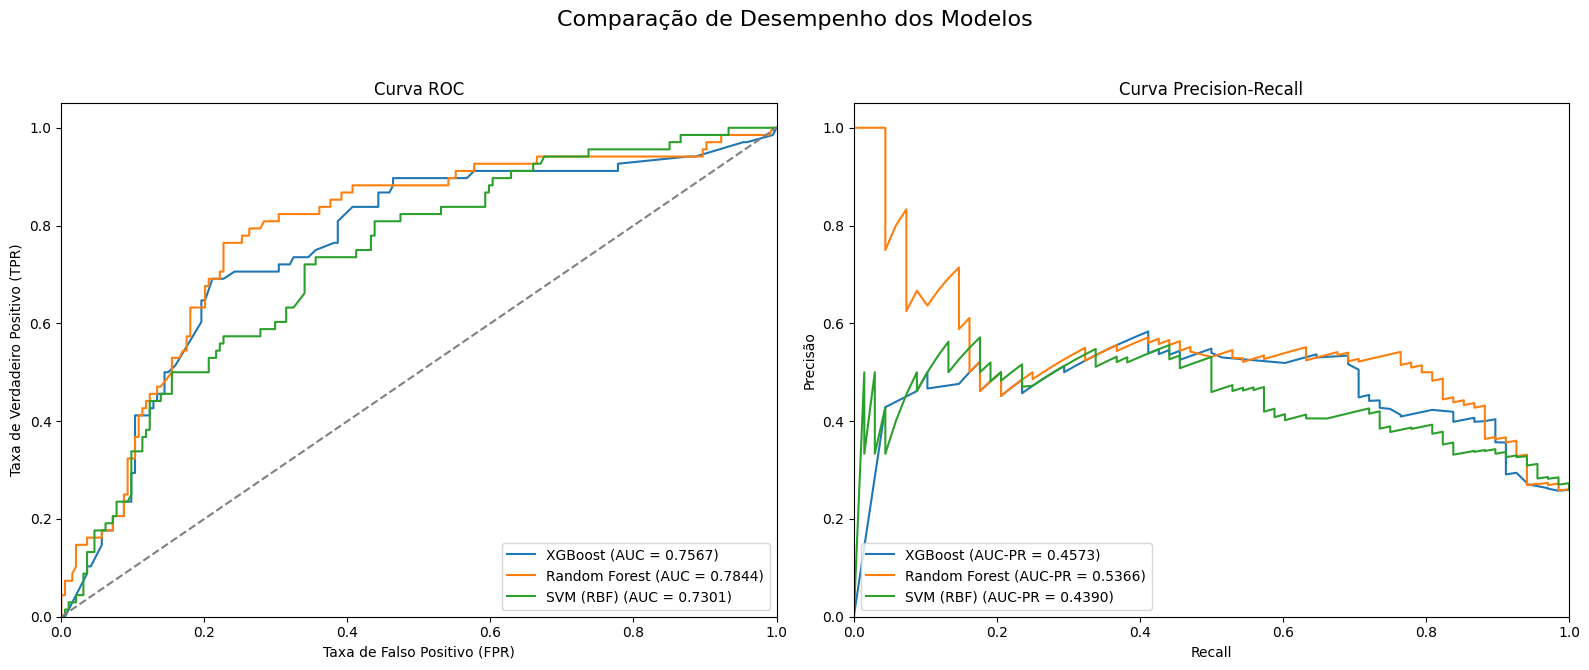

In [ ]:
plt.figure(figsize=(16, 7))

# Subplot 1: Curva ROC
ax1 = plt.subplot(1, 2, 1)
for model_name, data in best_models.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Taxa de Falso Positivo (FPR)')
ax1.set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")

# Subplot 2: Curva Precision-Recall
ax2 = plt.subplot(1, 2, 2)
for model_name, data in best_models.items():
    precision, recall, _ = precision_recall_curve(y_test, data['y_proba'])
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{model_name} (AUC-PR = {pr_auc:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisão')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")

plt.suptitle('Comparação de Desempenho dos Modelos', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

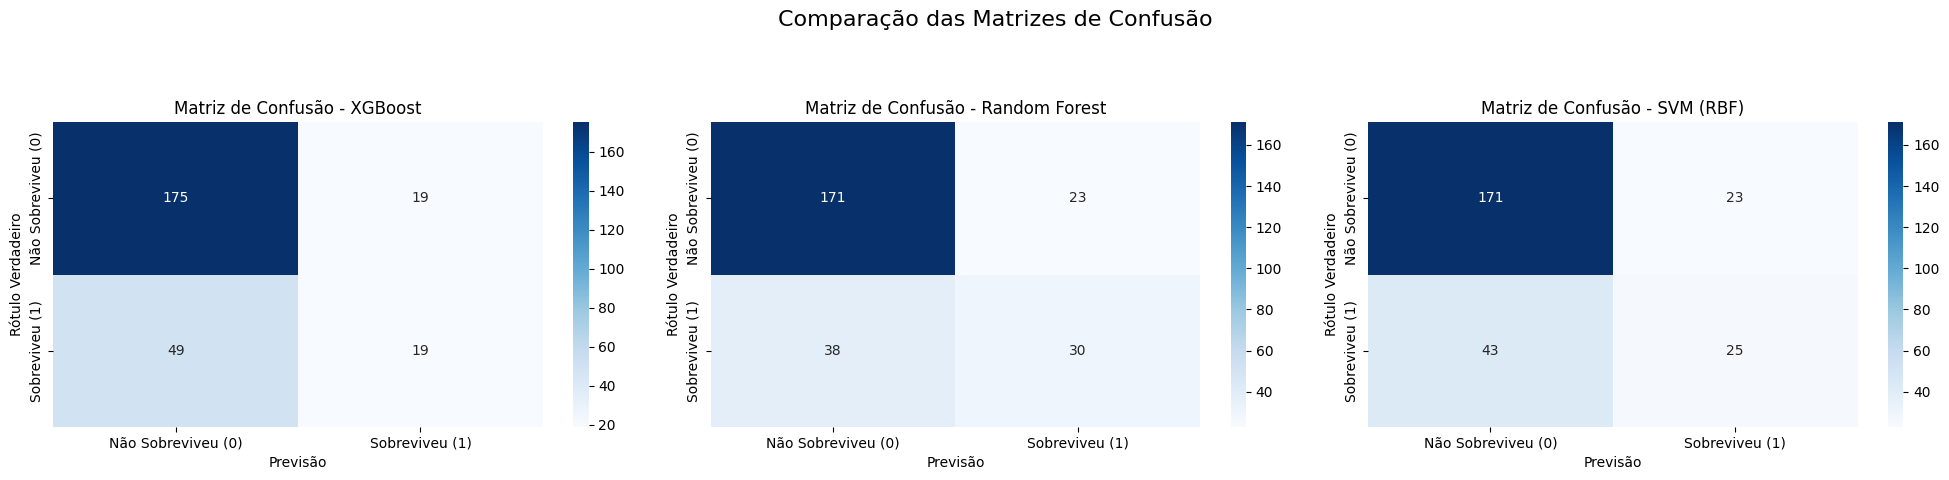

In [ ]:
plt.figure(figsize=(20, 5))

for i, (model_name, data) in enumerate(best_models.items()):
    ax = plt.subplot(1, 3, i + 1)
    cm = data['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Não Sobreviveu (0)', 'Sobreviveu (1)'],
                yticklabels=['Não Sobreviveu (0)', 'Sobreviveu (1)'])
    ax.set_title(f'Matriz de Confusão - {model_name}')
    ax.set_ylabel('Rótulo Verdadeiro')
    ax.set_xlabel('Previsão')

plt.suptitle('Comparação das Matrizes de Confusão', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

1-Com base na métrica principal, ROC-AUC, o XGBoost foi o modelo com melhor desempenho (AUC de 0.8710), indicando a melhor capacidade de discriminar entre sobreviventes e não sobreviventes.

2-Os modelos não sofreram overfitting significativo e estão generalizando bem para os dados de teste.

3-Valores Ausentes,Necessidade de Escalonamento.